In [10]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [11]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager

In [12]:
n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedata             = BaseLineDataLoaderManager(data_orchestrator)
graphdataloader_ig       = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdataloader_gn       = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdataloader_cm11     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_1').construct_dataloaders()
graphdataloader_cm12     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_2').construct_dataloaders()
graphdataloader_cm13     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_3').construct_dataloaders()
graphdataloader_cm14     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter14_4').construct_dataloaders()
graphdataloader_cm21     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()
graphdataloader_cm22     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_2').construct_dataloaders()
graphdataloader_cm23     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_3').construct_dataloaders()
graphdataloader_cm24     = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_4').construct_dataloaders()

In [13]:
from src.models import SimpleGCNModel, GATv2LSTMModel

In [14]:
mls_sgnn = []
mlns_sgnn= ['sgnn-ig','sgnn-gn','sgnn-cm11','sgnn-cm12','sgnn-cm13','sgnn-cm14','sgnn-cm21','sgnn-cm22','sgnn-cm23','sgnn-cm24']

for ii, dl in enumerate([graphdataloader_ig, graphdataloader_gn, graphdataloader_cm11, graphdataloader_cm12, graphdataloader_cm13, graphdataloader_cm14, graphdataloader_cm21, graphdataloader_cm22, graphdataloader_cm23, graphdataloader_cm24]):
    instancemodel = SimpleGCNModel(dl, name = mlns_sgnn[ii],verbose = 0)
    instancemodel.set_model_hparams(hidden_size=128)
    instancemodel.set_global_hparams(**global_hparams)
    instancemodel.train()
    instancemodel.forecast()
    mls_sgnn.append(instancemodel)


==                   sgnn-ig                    ==


Training epochs:  13%|█████████▏                                                             | 65/500 [04:27<29:53,  4.12s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3837


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 596.75it/s]


==                   sgnn-gn                    ==


...

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 623.03it/s]


==                  sgnn-cm24                   ==


Training epochs:  31%|█████████████████████▍                                                | 153/500 [02:49<06:23,  1.11s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.6035


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 612.61it/s]


In [15]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:12<00:00,  2.14s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

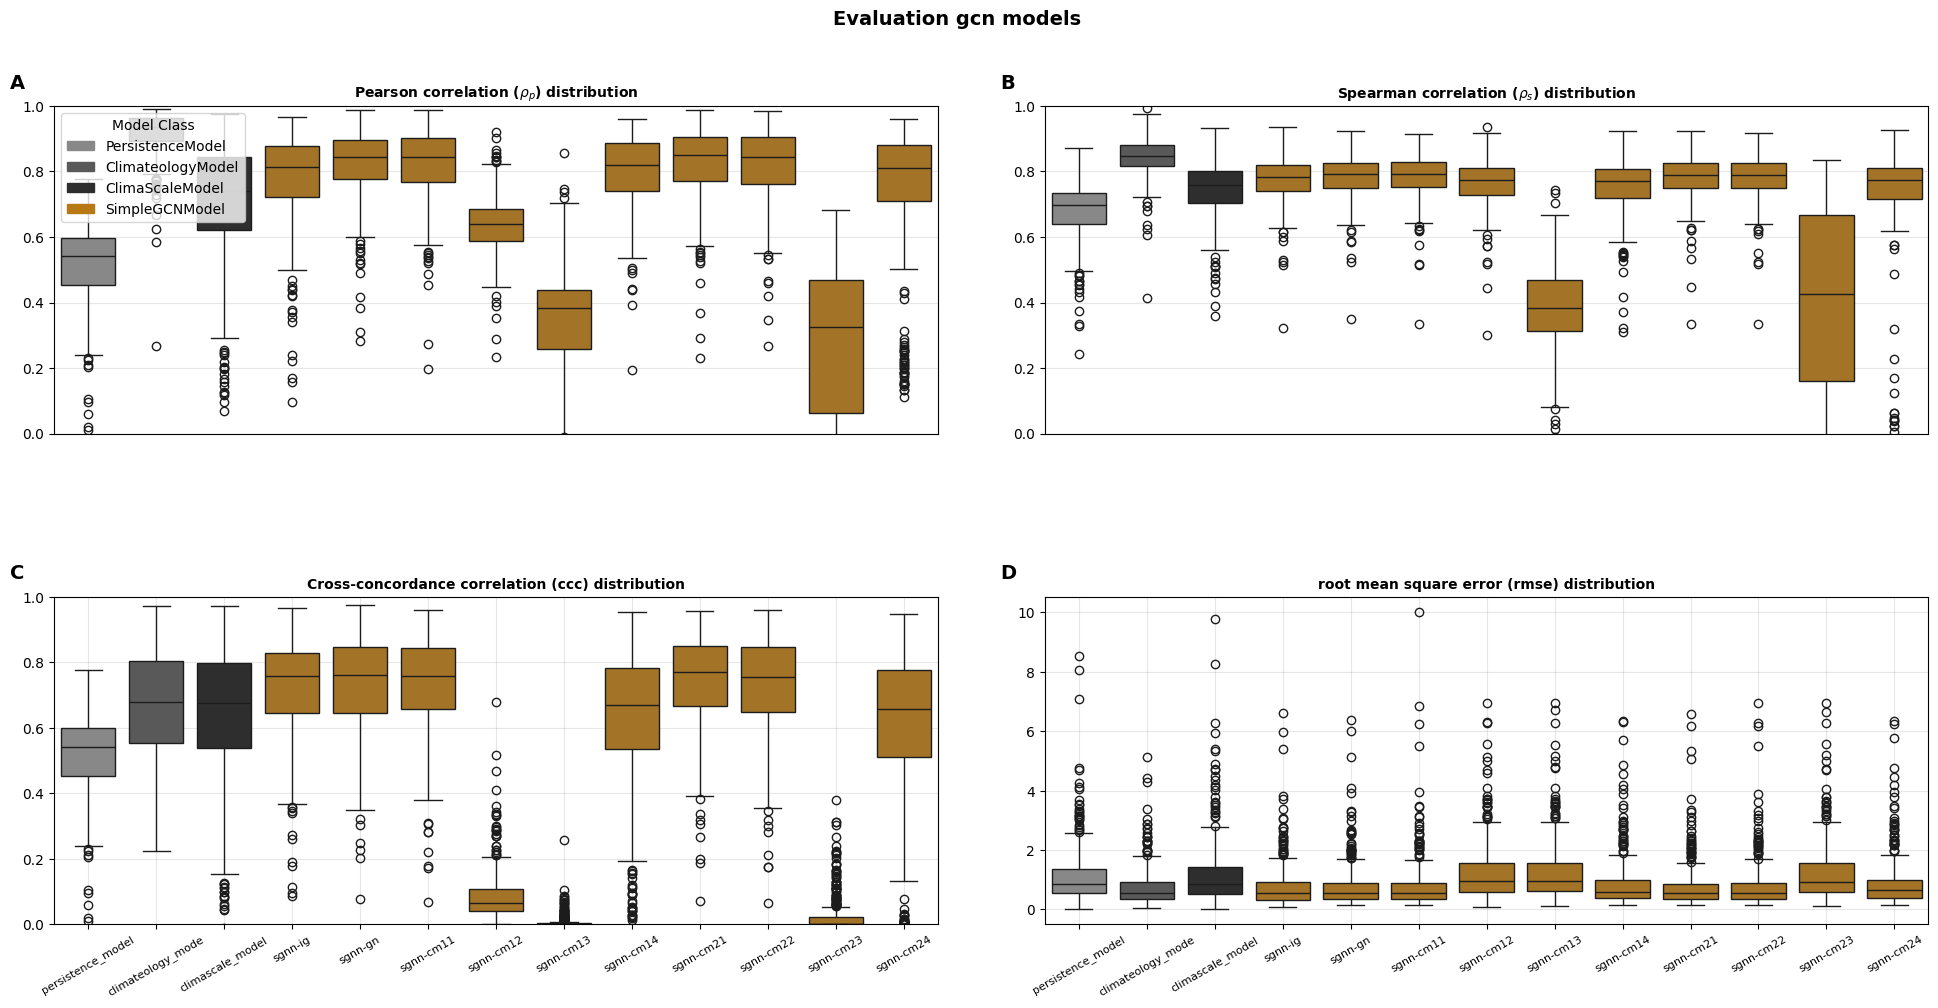

In [16]:
evaluation_experiment_sgnn = Evaluator(baseline_models + mls_sgnn).add_evaluation()
f_merged_raw    = evaluation_experiment_sgnn.plotter.plot_metric_compilation(subfig_size = (8,4), plot_types = ['box','box','box','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()

In [17]:
mls_stgnn = []
mlns_stgnn= ['stgnn-ig','stgnn-gn','stgnn-cm11','stgnn-cm12','stgnn-cm13','stgnn-cm14','stgnn-cm21','stgnn-cm22','stgnn-cm23','stgnn-cm24']

for ii, dl in enumerate([graphdataloader_ig, graphdataloader_gn, graphdataloader_cm11, graphdataloader_cm12, graphdataloader_cm13, graphdataloader_cm14, graphdataloader_cm21, graphdataloader_cm22, graphdataloader_cm23, graphdataloader_cm24]):
    instancemodel = GATv2LSTMModel(dl, name = mlns_stgnn[ii])
    instancemodel.set_model_hparams(hidden_size=128)
    instancemodel.set_global_hparams(**global_hparams)
    instancemodel.train()
    instancemodel.forecast()
    mls_stgnn.append(instancemodel)


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3674
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3595
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3549
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3730
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3898
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3825
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3638
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3703
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3808
E

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:14<00:00,  2.37s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

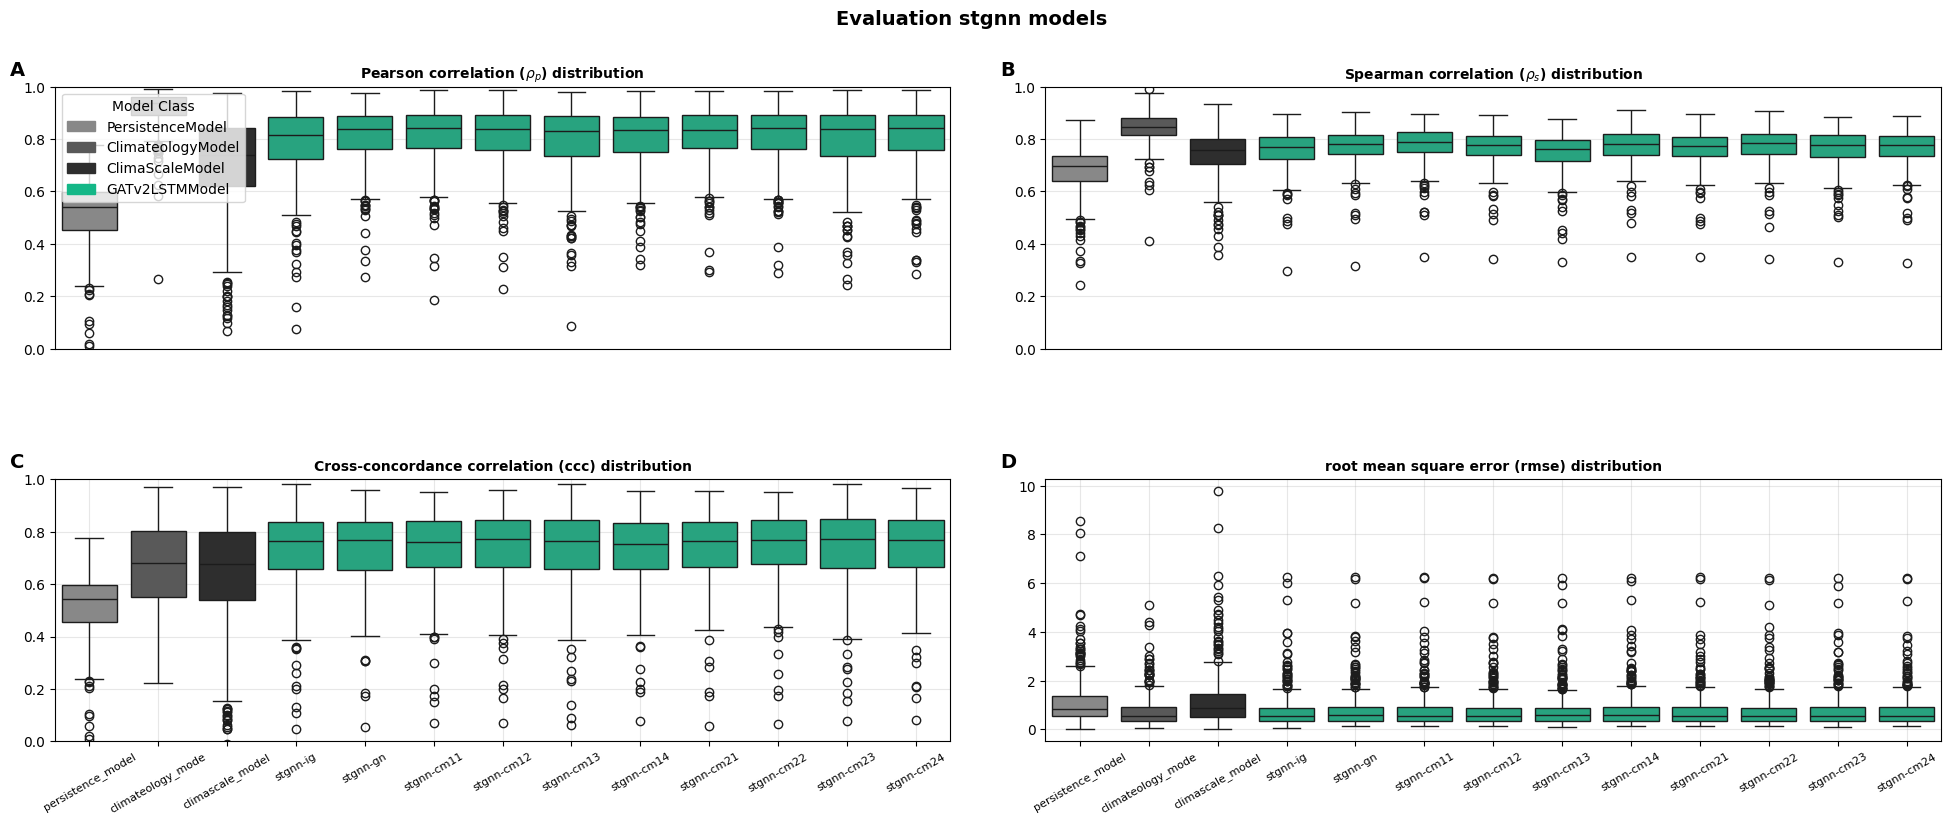

In [18]:
evaluation_experiment_stgnn = Evaluator(baseline_models + mls_stgnn).add_evaluation()
f_merged_raw    = evaluation_experiment_stgnn.plotter.plot_metric_compilation(subfig_size = (8,4), plot_types = ['box','box','box','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation stgnn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)       
    )
f_merged.show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:24<00:00,  4.07s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

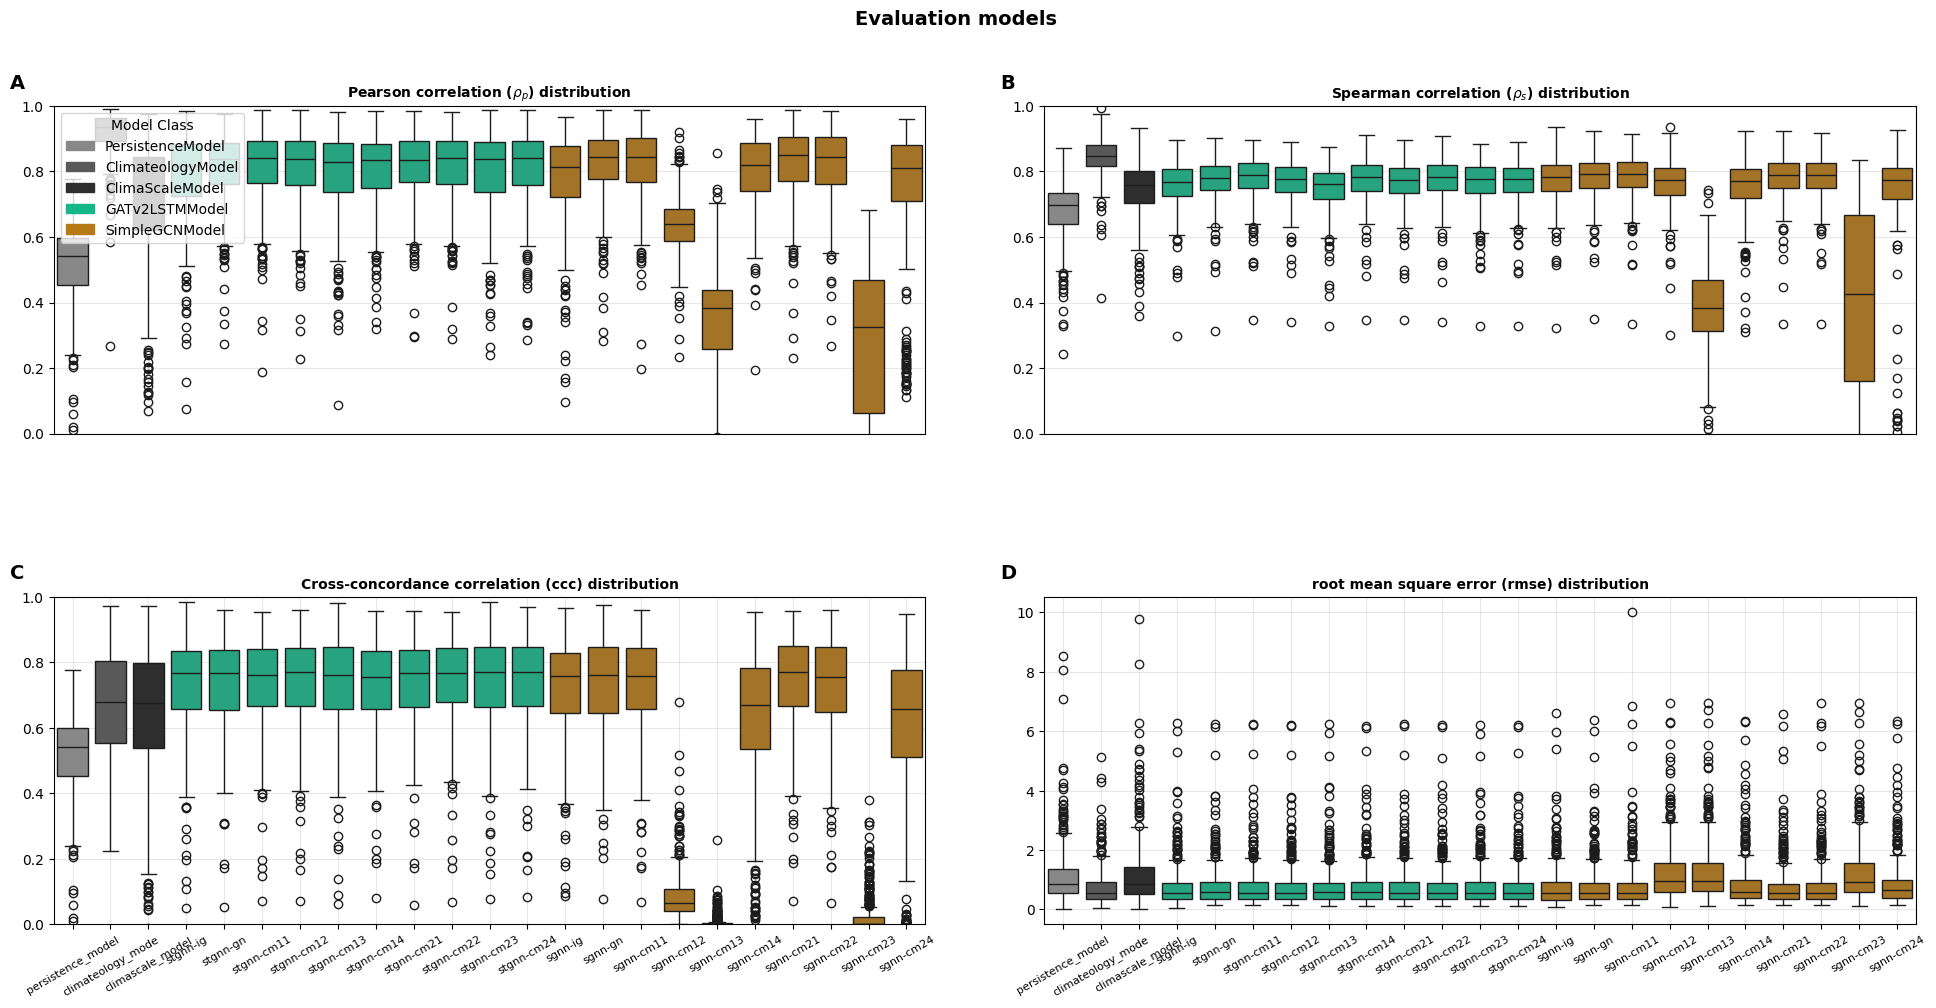

In [19]:
evaluation_experiment = Evaluator(baseline_models + mls_stgnn + mls_sgnn).add_evaluation()
f_merged_raw    = evaluation_experiment.plotter.plot_metric_compilation(subfig_size = (8,4), plot_types = ['box','box','box','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()